# Challenge Alura Store

## Importacion de Librerias

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


##Importacion de Datos


In [ ]:
url = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_1%20.csv"
url2 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_2.csv"
url3 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_3.csv"
url4 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_4.csv"

In [ ]:
tienda = pd.read_csv(url)
tienda2 = pd.read_csv(url2)
tienda3 = pd.read_csv(url3)
tienda4 = pd.read_csv(url4)

## Analisis Exploratorio

In [ ]:
tienda2.head()

,Producto,Categoría del Producto,Precio,Costo de envío,Fecha de Compra,Vendedor,Lugar de Compra,Calificación,Método de pago,Cantidad de cuotas,lat,lon
0,Silla de oficina,Muebles,283600.0,15300.0,04/08/2021,Izabela de León,Medellín,1,Nequi,1,6.25184,-75.56359
1,Pandereta,Instrumentos musicales,76800.0,2300.0,26/11/2020,Blanca Ramirez,Medellín,3,Tarjeta de crédito,4,6.25184,-75.56359
2,Cama king,Muebles,443300.0,23800.0,22/10/2021,Izabela de León,Pereira,5,Tarjeta de crédito,10,4.81333,-75.69611
3,Cama king,Muebles,906200.0,46400.0,04/05/2022,Maria Alfonso,Cali,5,Tarjeta de crédito,10,3.43722,-76.52250
4,Silla de oficina,Muebles,397800.0,19400.0,26/02/2022,Lucas Olivera,Bogotá,4,Tarjeta de crédito,3,4.60971,-74.08175


In [ ]:
tienda.describe()

,Precio,Costo de envío,Calificación,Cantidad de cuotas,lat,lon
count,2.359000e+03,2359.000000,2359.000000,2359.000000,2359.000000,2359.000000
mean,4.878679e+05,26018.609580,3.976685,2.943196,5.365283,-74.789417
std,6.146868e+05,32860.001783,1.415370,2.819897,2.287445,1.217827
min,7.600000e+03,0.000000,1.000000,1.000000,-4.215280,-77.281110
25%,5.575000e+04,3100.000000,3.000000,1.000000,4.609710,-75.563590
50%,2.353000e+05,12400.000000,5.000000,1.000000,4.609710,-74.199040
75%,6.781000e+05,36000.000000,5.000000,4.000000,6.251840,-74.081750
max,2.977000e+06,160800.000000,5.000000,24.000000,11.544440,-67.923900


In [ ]:
tienda.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2359 entries, 0 to 2358
Data columns (total 12 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Producto                2359 non-null   object 
 1   Categoría del Producto  2359 non-null   object 
 2   Precio                  2359 non-null   float64
 3   Costo de envío          2359 non-null   float64
 4   Fecha de Compra         2359 non-null   object 
 5   Vendedor                2359 non-null   object 
 6   Lugar de Compra         2359 non-null   object 
 7   Calificación            2359 non-null   int64  
 8   Método de pago          2359 non-null   object 
 9   Cantidad de cuotas      2359 non-null   int64  
 10  lat                     2359 non-null   float64
 11  lon                     2359 non-null   float64
dtypes: float64(4), int64(2), object(6)
memory usage: 221.3+ KB


In [ ]:
tienda.shape

(2359, 12)

In [ ]:
tienda.columns

Index(['Producto', 'Categoría del Producto', 'Precio', 'Costo de envío',
       'Fecha de Compra', 'Vendedor', 'Lugar de Compra', 'Calificación',
       'Método de pago', 'Cantidad de cuotas', 'lat', 'lon'],
      dtype='object')

In [ ]:
nombres_tiendas=['Tienda 1', 'Tienda 2', 'Tienda 3', 'Tienda 4']

## **1. Analisis de Facturacion**

In [ ]:
#funcion para calcular el ingreso total de cada tienda
def ingreso_total(tienda: pd.DataFrame) -> float:
  return tienda['Precio'].sum()

#recorremos la funcion para todos los df
df=[tienda, tienda2, tienda3, tienda4]
df_total=[]
j=1
for i in df:

  print(f'Ingreso total de tienda N {j}: ', ingreso_total(i))
  df_total.append(ingreso_total(i))
  j=j+1


Ingreso total de tienda N 1:  1150880400.0
Ingreso total de tienda N 2:  1116343500.0
Ingreso total de tienda N 3:  1098019600.0
Ingreso total de tienda N 4:  1038375700.0


In [ ]:
serie_totales=pd.Series(df_total, index=nombres_tiendas)

In [ ]:
import matplotlib.pyplot as plt

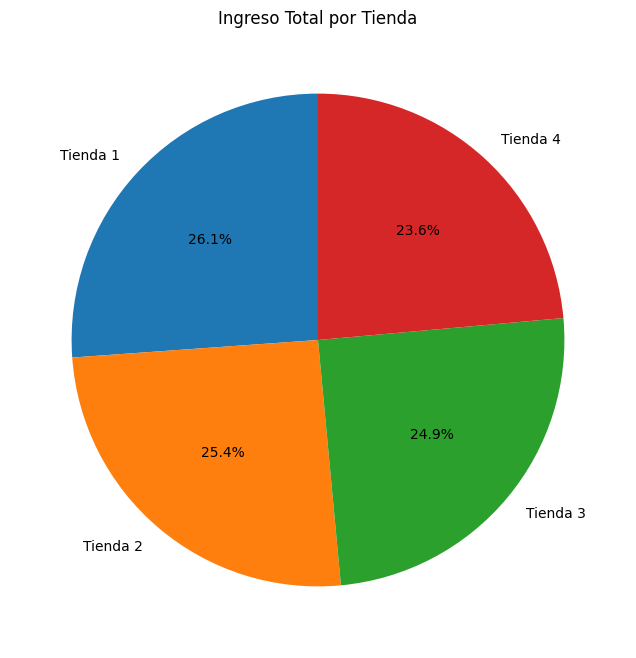

In [ ]:
#graficamos los resultados en un grafico pie para visualizar mejor
plt.figure(figsize=(8,8))

serie_totales.plot(
    kind='pie',
    autopct='%1.1f%%',   # mostrar porcentajes
    startangle=90        # rotación para que se vea mejor
)

plt.title('Ingreso Total por Tienda')
plt.ylabel('')  # quitar etiqueta vertical
plt.show()


## **2. Ventas por Categoria**

In [ ]:
#cantidad de productos vendidos por cada categoria en cada tienda


In [ ]:
#funcion para retornar la cantidad de cada producto
def ventas_por_categoria(tienda: pd.DataFrame) -> float:
  ventas=tienda.groupby('Categoría del Producto')['Producto'].count().sort_values(ascending=False)
  ventas=pd.Series(ventas, index=ventas.index)
  return ventas

In [ ]:
j=1
for i in df:
  # Convertir lista a Series
  index_categoria=ventas_por_categoria(i).index
  print(index_categoria)


  j=j+1

Index(['Muebles', 'Electrónicos', 'Juguetes', 'Electrodomésticos',
       'Deportes y diversión', 'Instrumentos musicales', 'Libros',
       'Artículos para el hogar'],
      dtype='object', name='Categoría del Producto')
Index(['Muebles', 'Electrónicos', 'Juguetes', 'Electrodomésticos',
       'Deportes y diversión', 'Instrumentos musicales', 'Libros',
       'Artículos para el hogar'],
      dtype='object', name='Categoría del Producto')
Index(['Muebles', 'Electrónicos', 'Juguetes', 'Electrodomésticos',
       'Deportes y diversión', 'Libros', 'Artículos para el hogar',
       'Instrumentos musicales'],
      dtype='object', name='Categoría del Producto')
Index(['Muebles', 'Electrónicos', 'Juguetes', 'Deportes y diversión',
       'Electrodomésticos', 'Artículos para el hogar', 'Libros',
       'Instrumentos musicales'],
      dtype='object', name='Categoría del Producto')


In [ ]:

tabla = pd.DataFrame()

for j, tienda in enumerate(df, start=1):

    ventas = ventas_por_categoria(tienda)   # ventas por categoria

    tabla[f'Tienda {j}'] = ventas

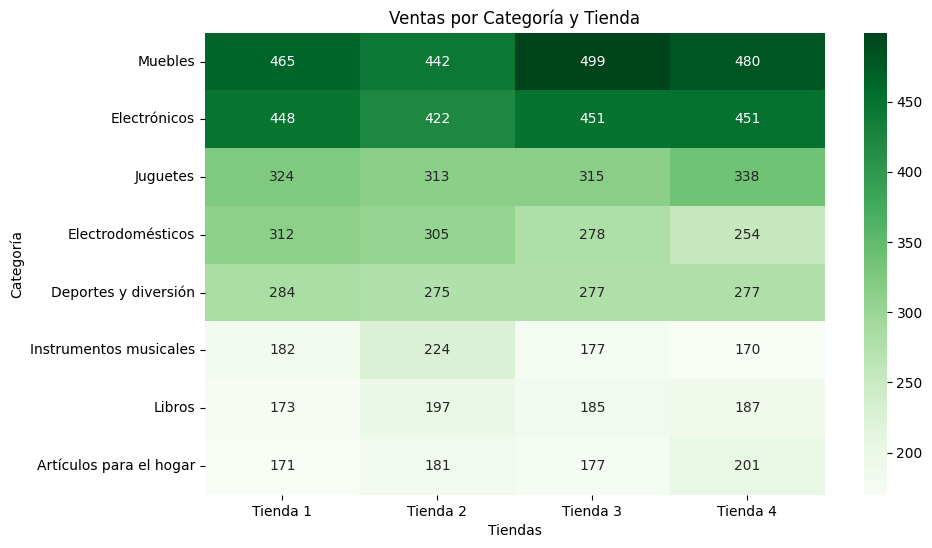

In [ ]:
import seaborn as sns
plt.figure(figsize=(10,6))

sns.heatmap(
    tabla,
    annot=True,        # mostrar números
    fmt="d",           # formato entero
    cmap="Greens"      # escala de colores
)

plt.title("Ventas por Categoría y Tienda")
plt.xlabel("Tiendas")
plt.ylabel("Categoría")
plt.show()

In [ ]:
#encontrar la categoria con la mayor venta por cada tienda
def ventas_por_categoria_maxima(tienda: pd.DataFrame):

    ventas = (
        tienda
        .groupby('Categoría del Producto')['Producto']
        .count()
    )

    categoria_max = ventas.idxmax()   # nombre categoría
    cantidad_max = ventas.max()       # cantidad

    return categoria_max, cantidad_max

In [ ]:
categorias = []
cantidades = []

for tienda in df:
    categoria, cantidad = ventas_por_categoria_maxima(tienda)

    categorias.append(categoria)
    cantidades.append(cantidad)

In [ ]:
maximos_grafica = pd.Series(
    cantidades,
    index=nombres_tiendas
)

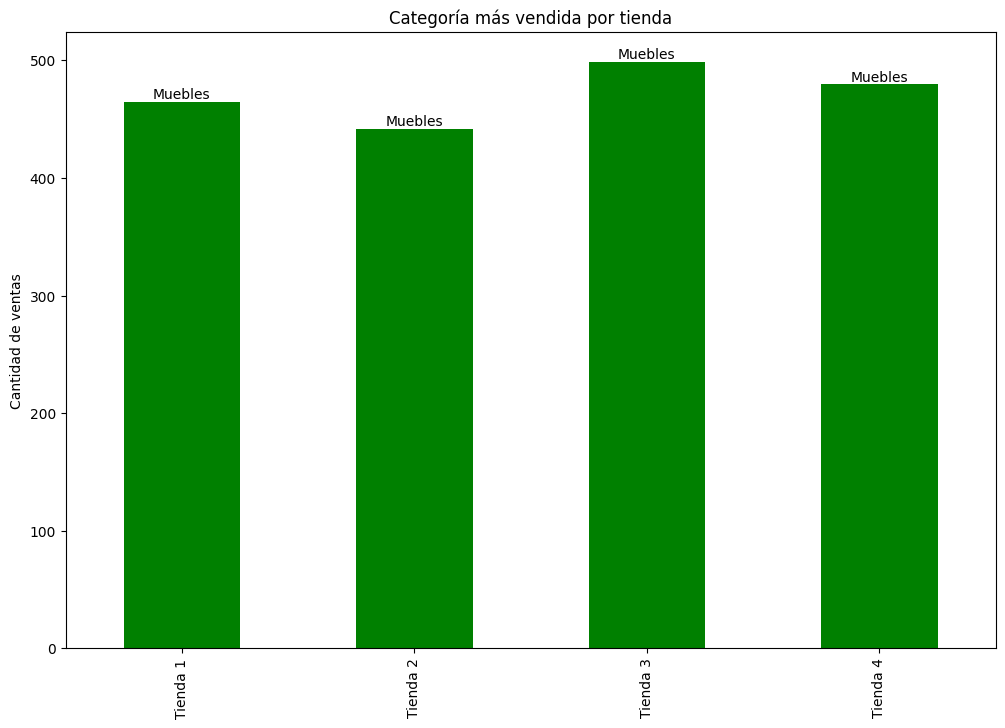

In [ ]:
plt.figure(figsize=(12,8))

ax = maximos_grafica.plot(
    kind='bar',
    color='green',
    title='Categoría más vendida por tienda'
)

#mostrar nombre de categoría encima de cada barra
for i, categoria in enumerate(categorias):
    ax.text(i, cantidades[i], categoria,
            ha='center', va='bottom', fontsize=10)

plt.ylabel("Cantidad de ventas")
plt.show()

In [ ]:
tienda2.groupby('Categoría del Producto')['Producto'].count().idxmax()


'Muebles'

In [ ]:
tienda.groupby('Categoría del Producto')['Producto'].count().sort_values(ascending=False).head(1)

,Producto
Categoría del Producto,
Muebles,480


## **3. Valoracion media por tienda**

In [ ]:
tienda['Calificación'].mean()

np.float64(3.9957591178965224)

In [ ]:
#funcion para calcular la valoracion media de cada tienda
def promedio_valiracion(tienda: pd.DataFrame):
  return tienda['Calificación'].mean()



In [ ]:
#recorrer todas las tiendas
calificacion=[]
for tienda in df:
  calificacion.append(promedio_valiracion(tienda))

print(calificacion)

#convertir en serie
calificacion_serie=pd.Series(calificacion, index=nombres_tiendas)
print(calificacion_serie)

[np.float64(3.976685036032217), np.float64(4.037303942348453), np.float64(4.048325561678677), np.float64(3.9957591178965224)]
Tienda 1    3.976685
Tienda 2    4.037304
Tienda 3    4.048326
Tienda 4    3.995759
dtype: float64


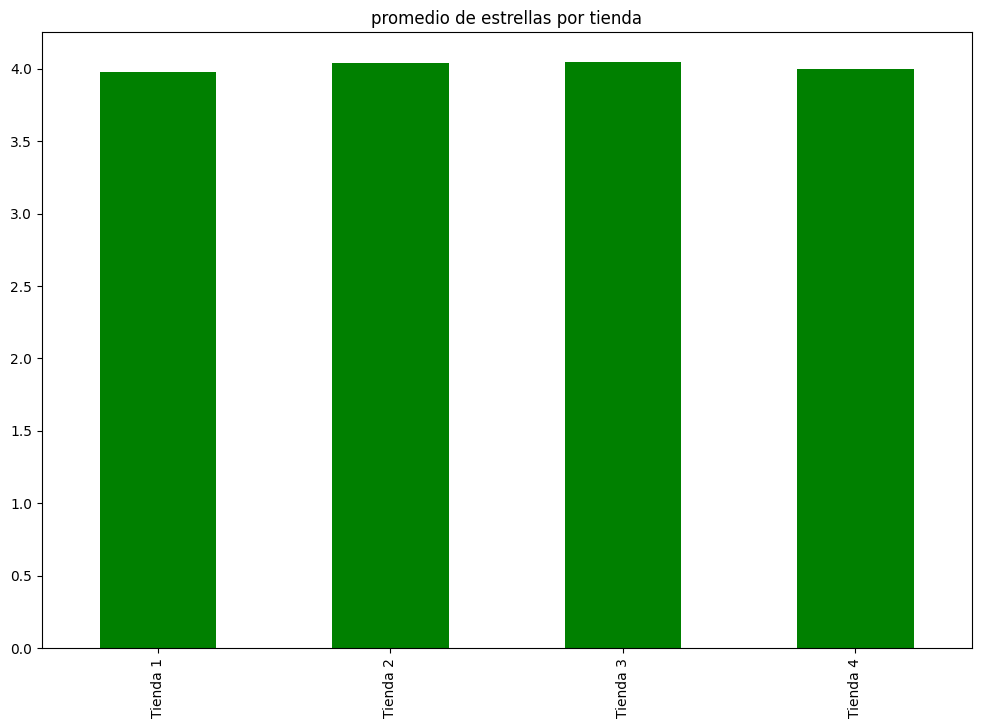

In [ ]:
plt.figure(figsize=(12,8))

ax = calificacion_serie.plot(
    kind='bar',
    color='green',
    title='promedio de estrellas por tienda'
)

## **4. Producto mas vendido y menos vendido**

In [ ]:
tienda['Producto'].count()

np.int64(2358)

In [ ]:
tienda.groupby('Producto')['Producto'].count().sort_values(ascending=False)

,Producto
Producto,
Cama box,62
Cubertería,59
Cama king,56
Dashboards con Power BI,56
Carrito de control remoto,55
Mesa de noche,55
Mesa de comedor,55
Bloques de construcción,54
Smart TV,54


In [ ]:
#funcion para calcular el producto mas vendido por tienda
def prod_max_medido(tienda: pd.DataFrame):
  ventas=tienda.groupby('Producto')['Producto'].count()
  producto=ventas.idxmax()
  cantidad=ventas.max()
  return producto, cantidad

#

In [ ]:
prod_max_medido(tienda)


('Cama box', 62)

In [ ]:
j=1
productos_max=[]
cantidades_max=[]
for tienda in df:
  print(f'Producto mas vendido de la tienda N: {j}')
  producto, cantidad = prod_max_medido(tienda)
  productos_max.append(producto)
  cantidades_max.append(cantidad)
  print(f'Producto: {producto}, ', f'Cantidad: {cantidad}')


  j=j+1

Producto mas vendido de la tienda N: 1
Producto: Armario,  Cantidad: 60
Producto mas vendido de la tienda N: 2
Producto: Iniciando en programación,  Cantidad: 65
Producto mas vendido de la tienda N: 3
Producto: Kit de bancas,  Cantidad: 57
Producto mas vendido de la tienda N: 4
Producto: Cama box,  Cantidad: 62


In [ ]:
print(productos_max)

['Armario', 'Iniciando en programación', 'Kit de bancas', 'Cama box']


In [ ]:
#funcion para calcular el producto menos vendido por tienda
def prod_min_medido(tienda: pd.DataFrame):
  ventas=tienda.groupby('Producto')['Producto'].count()
  producto=ventas.idxmin()
  cantidad=ventas.min()
  return producto, cantidad

In [ ]:
prod_min_medido(tienda)
#

('Guitarra eléctrica', 33)

In [ ]:
j=1
productos_min=[]
cantidades_min=[]
for tienda in df:
  print(f'Producto menos vendido de la tienda N: {j}')
  producto, cantidad = prod_min_medido(tienda)
  productos_min.append(producto)
  cantidades_min.append(cantidad)
  print(f'Producto: {producto}, ', f'Cantidad: {cantidad}')


  j=j+1

Producto menos vendido de la tienda N: 1
Producto: Auriculares con micrófono,  Cantidad: 33
Producto menos vendido de la tienda N: 2
Producto: Juego de mesa,  Cantidad: 32
Producto menos vendido de la tienda N: 3
Producto: Bloques de construcción,  Cantidad: 35
Producto menos vendido de la tienda N: 4
Producto: Guitarra eléctrica,  Cantidad: 33


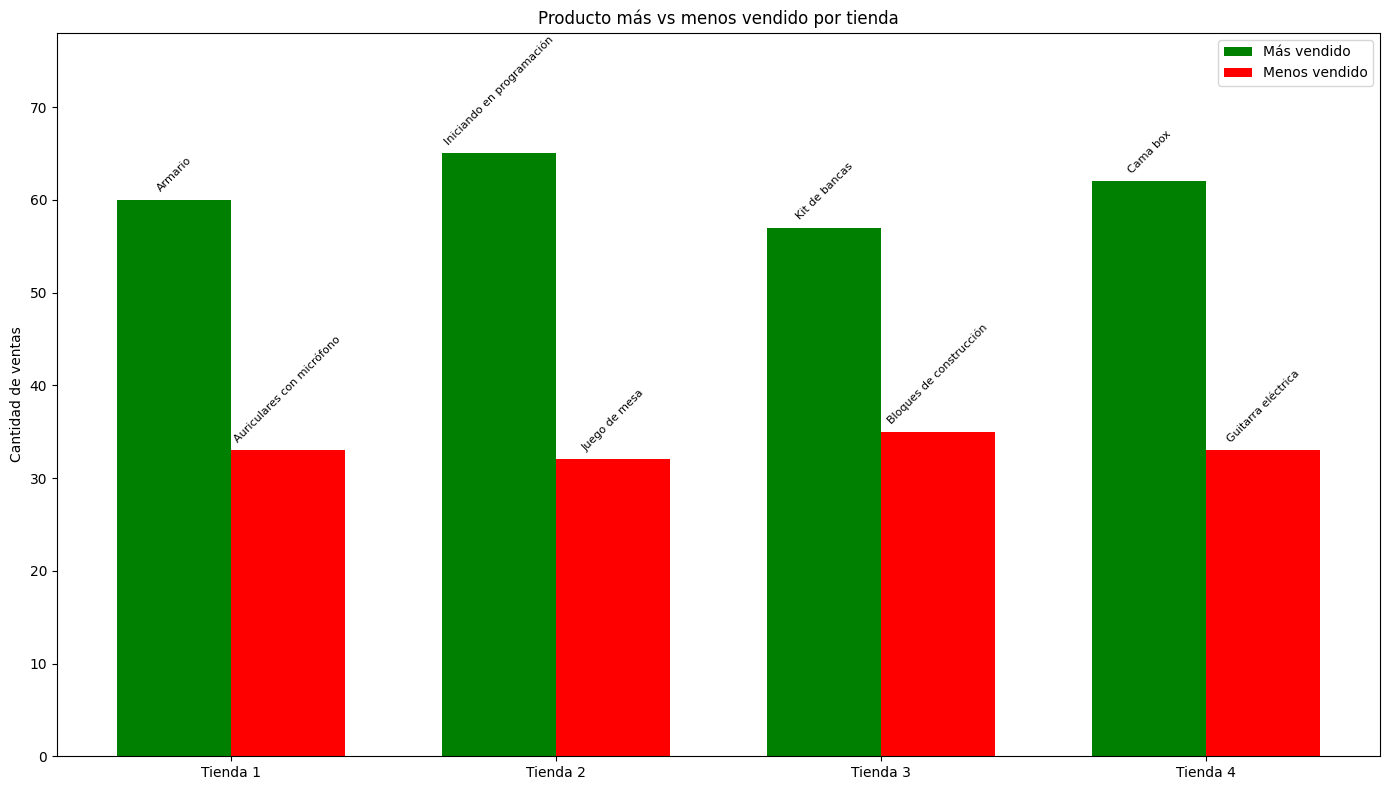

In [ ]:
x = np.arange(len(nombres_tiendas))
width = 0.35

fig, ax = plt.subplots(figsize=(14, 8))  # Usar ax

bars1 = ax.bar(x - width/2, cantidades_max, width, label="Más vendido", color="green")
bars2 = ax.bar(x + width/2, cantidades_min, width, label="Menos vendido", color="red")

ax.set_xticks(x)
ax.set_xticklabels(nombres_tiendas)
ax.set_ylabel("Cantidad de ventas")
ax.set_title("Producto más vs menos vendido por tienda")
ax.legend()

# Agregar margen superior para que quepan las etiquetas
y_max = max(max(cantidades_max), max(cantidades_min))
ax.set_ylim(0, y_max * 1.2)  # 20% extra de espacio arriba

for i in range(len(x)):
    ax.text(
        x[i] - width/2,
        cantidades_max[i] + y_max * 0.01,  # pequeño offset
        productos_max[i],
        ha='center',
        va='bottom',
        fontsize=8,
        rotation=45  # rotar si los nombres son largos
    )
    ax.text(
        x[i] + width/2,
        cantidades_min[i] + y_max * 0.01,
        productos_min[i],
        ha='center',
        va='bottom',
        fontsize=8,
        rotation=45
    )

plt.tight_layout()  # Evita que elementos se corten
plt.show()

## **5. Valor del envío promedio por tienda**

In [ ]:
tienda.head()

,Producto,Categoría del Producto,Precio,Costo de envío,Fecha de Compra,Vendedor,Lugar de Compra,Calificación,Método de pago,Cantidad de cuotas,lat,lon
0,Lavavajillas,Electrodomésticos,1084800.0,56000.0,11/11/2022,Rafael Acosta,Bogotá,4,Tarjeta de crédito,3,4.60971,-74.08175
1,Cama box,Muebles,473800.0,25400.0,03/01/2020,Izabela de León,Cúcuta,5,Tarjeta de crédito,2,7.89391,-72.50782
2,Balón de baloncesto,Deportes y diversión,23700.0,0.0,25/12/2022,Maria Alfonso,Medellín,5,Nequi,1,6.25184,-75.56359
3,Modelado predictivo,Libros,57700.0,1300.0,23/11/2021,Lucas Olivera,Medellín,3,Nequi,1,6.25184,-75.56359
4,Auriculares,Electrónicos,138900.0,5600.0,25/04/2022,Blanca Ramirez,Bogotá,4,Tarjeta de crédito,7,4.60971,-74.08175


In [ ]:
tienda['Costo de envío'].mean()

np.float64(23459.457167090754)

In [ ]:
#funcion para calcular el costo de envio promedio por tienda
def envio_promedio(tienda: pd.DataFrame):
  return tienda['Costo de envío'].mean()


In [ ]:
costos_envio=[]
for tienda in df:
  costos_envio.append(envio_promedio(tienda))

print(costos_envio)

[np.float64(26018.60958033065), np.float64(25216.235693090293), np.float64(24805.680373039424), np.float64(23459.457167090754)]


In [ ]:
#transformar en una serie de pandas
costos_envio_serie=pd.Series(costos_envio, index=nombres_tiendas)
print(costos_envio_serie)

Tienda 1    26018.609580
Tienda 2    25216.235693
Tienda 3    24805.680373
Tienda 4    23459.457167
dtype: float64


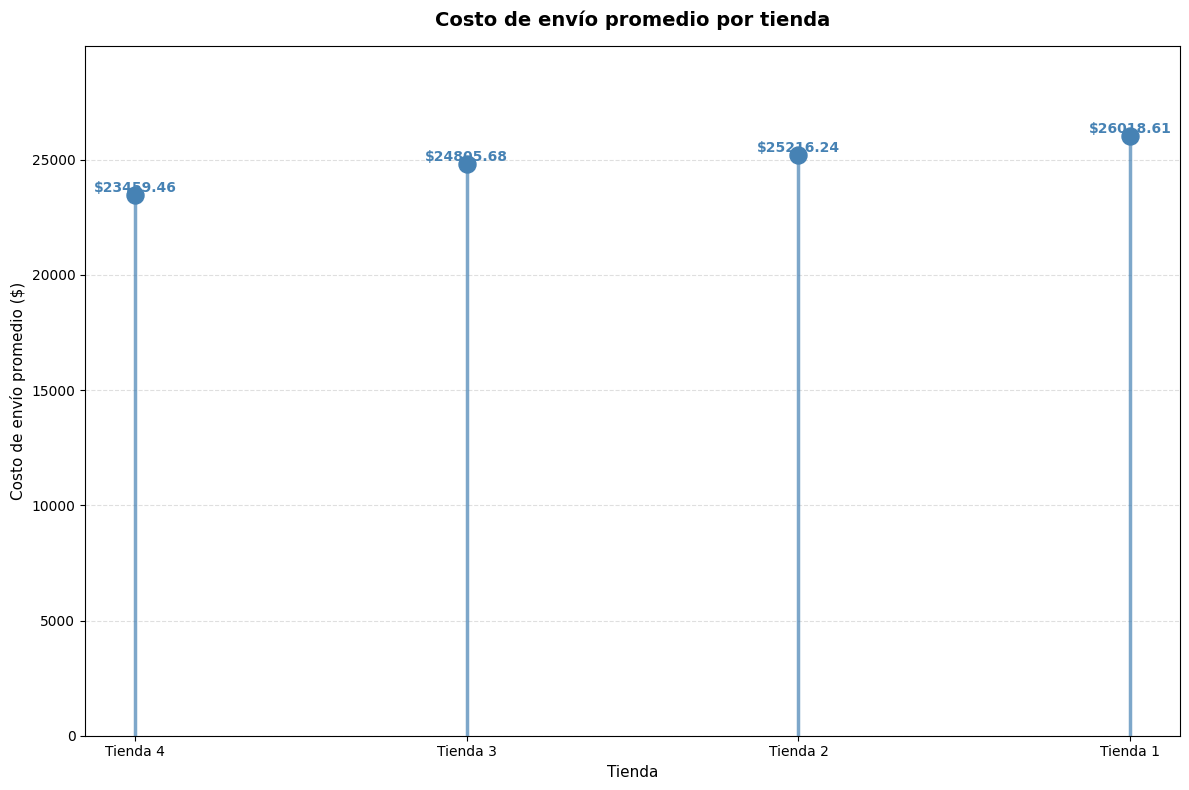

In [ ]:
# Gráfico de Piruleta (Lollipop Chart) - Costo de envío promedio por tienda
plt.figure(figsize=(12, 8))

costos_envio_serie_sorted = costos_envio_serie.sort_values()


plt.vlines(
    x=costos_envio_serie_sorted.index,
    ymin=0,
    ymax=costos_envio_serie_sorted.values,
    color='steelblue',
    linewidth=2.5,
    alpha=0.7
)


plt.scatter(
    x=costos_envio_serie_sorted.index,
    y=costos_envio_serie_sorted.values,
    color='steelblue',
    s=150,       # tamaño del punto
    zorder=3     # asegura que el punto quede encima de la línea
)

# 3. Etiquetas con el valor exacto sobre cada punto
for tienda, valor in costos_envio_serie_sorted.items():
    plt.text(
        tienda,
        valor + 0.5,
        f'${valor:.2f}',
        ha='center',
        va='bottom',
        fontsize=10,
        fontweight='bold',
        color='steelblue'
    )

# Configuración del gráfico
plt.title('Costo de envío promedio por tienda', fontsize=14, fontweight='bold', pad=15)
plt.ylabel('Costo de envío promedio ($)', fontsize=11)
plt.xlabel('Tienda', fontsize=11)
plt.ylim(0, costos_envio_serie_sorted.max() * 1.15)  # espacio para las etiquetas
plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

## **Informe Final**

El presente informe tiene como propósito evaluar el desempeño operativo y financiero de cuatro sucursales (Tienda 1, 2, 3 y 4) pertenecientes al portafolio comercial del Sr. Juan. A través de un Análisis Exploratorio de Datos (EDA), se han evaluado factores clave como el volumen de facturación, la preferencia de categorías y productos, la satisfacción del cliente y los costos logísticos. El objetivo final es proporcionar una recomendación basada en datos sobre qué tienda debería ser vendida (liquidada o traspasada) para optimizar la rentabilidad del negocio.

El análisis comparativo de las cuatro sucursales revela contrastes importantes en su funcionamiento:

1. Ingresos Totales (Facturación): Existe una brecha significativa en la generación de ingresos. La Tienda 1 lidera indiscutiblemente las ventas con un total,  seguida por la Tienda 2  y la Tienda 3. En el último lugar se encuentra la Tienda 4, con la facturación más baja del grupo: $1,038

2. Categorías más y menos vendidas: El comportamiento del consumidor es consistente en las cuatro sucursales. La categoría estrella en todas las tiendas es "Muebles", seguida de cerca por "Electrónicos" y "Juguetes". Las categorías con menor rotación tienden a ser "Instrumentos musicales" y "Libros", marcando una clara preferencia del público por bienes duraderos para el hogar.

3. Calificación Promedio de Clientes: La satisfacción general es positiva, rozando las 4 estrellas en todas las ubicaciones. Sin embargo, destacan la Tienda 3 (4.04) y la Tienda 2 (4.03) por su excelente servicio. En contraste, la Tienda 1 (3.97) y la Tienda 4 (3.99) presentan valoraciones ligeramente inferiores, lo que indica oportunidades de mejora en la atención al cliente o calidad del servicio.

4. Productos más y menos vendidos: El análisis granular por producto refleja las fortalezas específicas de cada inventario:

- Los más exitosos: Armario (Tienda 1 - 60 uds), Curso "Iniciando en programación" (Tienda 2 - 65 uds), Kit de bancas (Tienda 3 - 57 uds) y Cama box (Tienda 4 - 62 uds).

- Los menos exitosos: Auriculares con micrófono (Tienda 1 - 33 uds), Juego de mesa (Tienda 2 - 32 uds), Bloques de construcción (Tienda 3 - 35 uds) y Guitarra eléctrica (Tienda 4 - 33 uds).

Considerando las fortalezas y debilidades de cada sucursal, la recomendación para el Sr. Juan es vender (traspasar/liquidar) la Tienda 4.

Justificación de la decisión:
A pesar de que la Tienda 4 cuenta con una ventaja operativa al tener el costo de envío promedio más bajo , es incapaz de transformar esa ventaja en rentabilidad. Es la sucursal con el nivel de facturación más bajo , quedando rezagada por más de 112 millones frente a la Tienda 1.

Además, su calificación promedio de satisfacción (3.99) está por debajo de tiendas como la 2 y la 3, demostrando que no ha logrado fidelizar a sus clientes a través de un servicio excepcional. Por lo tanto, desde una perspectiva financiera, la Tienda 4 es el eslabón más débil del portafolio. Liquidar esta tienda permitiría al Sr. Juan reasignar ese capital y esfuerzo logístico para potenciar la Tienda 1 (que tiene el mayor poder de ingresos) o la Tienda 3 (que demuestra la mayor lealtad y satisfacción del cliente).

## **EXTRA: Análisis del desempeño geográfico**

In [ ]:
tienda.head()

,Producto,Categoría del Producto,Precio,Costo de envío,Fecha de Compra,Vendedor,Lugar de Compra,Calificación,Método de pago,Cantidad de cuotas,lat,lon
0,Asistente virtual,Electrónicos,164300.0,6900.0,16/01/2021,Pedro Gomez,Bogotá,4,Tarjeta de crédito,8,4.60971,-74.08175
1,Mesa de comedor,Muebles,192300.0,8400.0,18/05/2022,Beatriz Morales,Medellín,1,Tarjeta de crédito,4,6.25184,-75.56359
2,Juego de mesa,Juguetes,209600.0,15900.0,15/03/2021,Juan Fernandez,Cartagena,1,Tarjeta de crédito,1,10.39972,-75.51444
3,Microondas,Electrodomésticos,757500.0,41000.0,03/05/2022,Juan Fernandez,Cali,4,Nequi,1,3.43722,-76.52250
4,Silla de oficina,Muebles,335200.0,20200.0,07/11/2020,Maria Alfonso,Medellín,5,Nequi,1,6.25184,-75.56359
